## Preprocessing


This code was created on Aug 7th, expands on code "00".

In [1]:
# Goal: be in  "/Users/adrian/Documents/01_projects/14_4D_lab".
import os

print("Working dir is now:", os.getcwd())

DATA_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/data"
OUTPUT_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/output/01_notebook_experiments"

PREPROCESSED_PATH = DATA_PATH + "/preprocessed/01_first_analysises"

# create output path if it does not exist
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

if not os.path.exists(PREPROCESSED_PATH):
    os.makedirs(PREPROCESSED_PATH)

Working dir is now: /Users/adrian/Documents/01_projects/14_4D_lab


In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd
from pathlib import Path

import logging
from typing import Dict, List, Tuple, Iterable, Optional

import numpy as np
import scipy.io
import scipy.sparse as sp
import matplotlib.pyplot as plt

try:
    from netneurotools.networks import threshold_network
except ImportError:  # pragma: no cover - optional dependency
    threshold_network = None  # type: ignore

logger = logging.getLogger(__name__)

## Distance Matrix

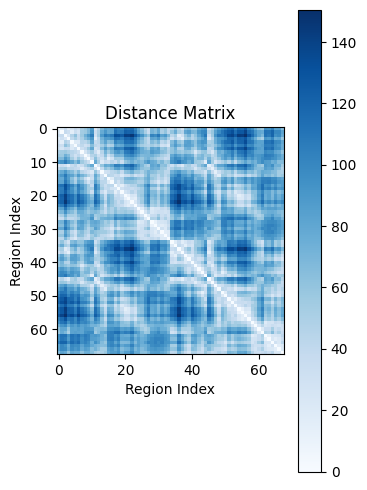

In [3]:
# Assumption: 
# - There is no distance matrix yet. 
# - weighted_adj_matrix: raw structural connectivity (i.e. number of streamlines)
# - fc_mat: Functional connectivity 
# - fiber_length_mat: streamline lengths 
# -> Thus, the distance matrix is calculated from the coordinate file

# Distance matrix 
coords = np.loadtxt(DATA_PATH + "/preprocessed/00_just_converted_for_matlab_and_python/data_10_consensus/04_coordinates_68.csv", delimiter=",")
dist_mat = np.linalg.norm(coords[:, None] - coords[None, :], axis=-1) # pairwise Euclidean distances
np.fill_diagonal(dist_mat, 0.0)
# now dist_mat is symmetric with zeros on the diagonal


# plot it 
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(dist_mat, cmap='Blues') 
plt.colorbar()
plt.title("Distance Matrix")
plt.xlabel("Region Index")
plt.ylabel("Region Index")
plt.tight_layout()

# Sanity checks: 
# - it is symmetric
# - diagonal is 0
assert np.allclose(dist_mat, dist_mat.T), "Distance matrix is not symmetric!"
assert np.all(np.diag(dist_mat) == 0), "Diagonal of distance matrix is not zero!"

dist_mat.shape # (68, 68)

# save distance matrix
np.save(PREPROCESSED_PATH + "/distance_matrix.npy", dist_mat)

## Individual connectomes

In [4]:
# get individual connectomes from 70 subjects

# Open the MAT-file as an HDF5 container. Loading with "sio.loadmat" does not work here, as the matlab version is too new (v7.3+).
import h5py

with h5py.File(DATA_PATH + "/preprocessed/00_just_converted_for_matlab_and_python/data_700mb_individual_connectomes/SC_68.mat", "r") as f:
    all_connectomes = np.array(f["M"]).T
    print("Data shape:", all_connectomes.shape) # (68, 68, 70) -> 68 regions, 68 regions, 70 subjects


# Check the minimal value of all connectomes (to ensure no negative distances)
print("Statistics of all connectomes:\n",
    "Min:", np.min(all_connectomes), "\n",
    "Max:", np.max(all_connectomes), "\n",
    "Mean:", np.mean(all_connectomes), "\n",
    "Std:", np.std(all_connectomes))


# The connectomes sometimes have diagonal values that are not zero, so they are now set to zero
for i in range(1, all_connectomes.shape[0]):
    all_connectomes[i,:,:][np.diag_indices_from(all_connectomes[i,:,:])] = 0.0
    # print(f"Checking connectome {i+1}...")
    # print(all_connectomes[i,:,:].shape)
    assert np.all(np.diag(all_connectomes[i,:,:]) == 0), "Diagonal of distance matrix is not zero!"

# Sanity check:
# - check if diagonal is zero for all connectomes
for i in range(1, all_connectomes.shape[0]):
    # print(f"Checking connectome {i+1}...")
    # print(all_connectomes[i,:,:].shape)
    assert np.all(np.diag(all_connectomes[i,:,:]) == 0), "Diagonal of distance matrix is not zero!"

nsub, n, _ = all_connectomes.shape
print(f"{nsub} subjects | {n} × {n} matrices")

# Save the connectomes as numpy arrays
np.save(PREPROCESSED_PATH + "/all_connectomes.npy", all_connectomes)

Data shape: (70, 68, 68)
Statistics of all connectomes:
 Min: 0.0 
 Max: 0.12189800837138423 
 Mean: 0.0009902234262211787 
 Std: 0.004209923846361063
70 subjects | 68 × 68 matrices


## Absolute thresholding of structural networks




In [5]:
# Consensus- and absolute-thresholding of structural networks re-implementation of Alexa Mousley’s MATLAB script


consensus_frac = 0.60 # Percentage threshold
min_count      = int(np.floor(nsub * consensus_frac)) # Calculate threshold value based on the number of subjects

# mask of edges that appear in ≥ min_count subjects
edge_presence  = (all_connectomes != 0).sum(axis=0) # Find nonzero elements in all connectomes, and making a mask out of it, (n, n)
consensus_mask = edge_presence >= min_count # mask of edges that appear in at least min_count subjects

# apply mask to every subject
consensus_thr  = all_connectomes.copy()
consensus_thr[:, ~consensus_mask] = 0          # vectorised broadcasting

# quick sanity check — connection counts before / after
before = (all_connectomes != 0).sum(axis=(1, 2)) / 2 # Count the number of nonzero elements in each connectome, divided by 2 (as the matrix is symmetric)
after  = (consensus_thr != 0).sum(axis=(1, 2)) / 2
print(f"Mean edges  before consensus: {before.mean():.1f}")
print(f"Mean edges after  consensus: {after.mean():.1f}")


Mean edges  before consensus: 611.3
Mean edges after  consensus: 452.2


In [6]:
import numpy as np
import bct 

def _threshold_absolute(W, thr):
    """Return a copy of W with weights < thr set to 0 (diagonal left untouched)."""
    Wthr = W.copy()
    Wthr[Wthr < thr] = 0
    return Wthr

# def _density_und(Wbin):
#     """Edge density of an undirected binary / weighted matrix (loops excluded)."""
#     n = Wbin.shape[0]
#     m = np.count_nonzero(np.triu(Wbin, k=1))
#     return m / (n * (n - 1) / 2)

def binarize_to_fixed_density(connectomes, target=0.10, max_iter=50, tol=1e-4):
    """
    Parameters
    ----------
    connectomes : (S, n, n) ndarray
        Weighted undirected adjacency matrices, one per subject (S = subjects).
    target : float
        Desired undirected density (0–1). 0.10 → 10 % of all possible edges.
    max_iter : int
        Safety cap on binary-search iterations.
    tol : float
        Stop if |density-target| < tol.

    Returns
    -------
    bin_conn : (S, n, n) int8
        Binarised matrices at exactly (or very close to) the target density.
    density  : (S,) float
        Final density per subject (should all be ≈ target).
    thr_used : (S,) float
        Absolute weight threshold chosen for each subject.
    """
    subj, n, _ = connectomes.shape
    bin_conn   = np.zeros_like(connectomes, dtype=np.int8)
    density    = np.zeros(subj)
    thr_used   = np.zeros(subj)

    for s in range(subj):
        W = connectomes[s]

        # extract all positive, upper-triangular weights (no diag) – sorted
        iu = np.triu_indices(n, k=1)
        weights = W[iu]
        weights = weights[weights > 0]

        if len(weights) == 0:
            raise ValueError(f"Subject {s}: matrix is empty (all zeros)")

        lo, hi = weights.min(), weights.max()
        best_thr = lo
        best_density = bct.density_und((W >= best_thr).astype(int))[0] # density, dim_1, dim_2.

        for _ in range(max_iter):
            mid = (lo + hi) / 2
            Wmid = _threshold_absolute(W, mid)
            dmid = bct.density_und(Wmid)[0] # density, dim_1, dim_2. 

            # update best if this is closer
            if abs(dmid - target) < abs(best_density - target):
                best_thr, best_density = mid, dmid

            # perfect (within tol) → done
            if abs(dmid - target) < tol:
                best_thr, best_density = mid, dmid
                break

            # binary-search decision
            if dmid >= target:
                # still too many edges → raise threshold
                lo = mid
            else:
                # too sparse → lower threshold
                hi = mid

        # apply best threshold, binarise and store
        Wsel = _threshold_absolute(W, best_thr)
        B    = (Wsel > 0).astype(np.int8)
        # force symmetry & zero diagonal (just in case)
        B    = np.triu(B, k=1)
        B    = B + B.T
        bin_conn[s]  = B
        density[s]   = best_density
        thr_used[s]  = best_thr

    return bin_conn, density, thr_used


densities (mean ± sd) : 0.20018 ± 0.00000


(70, 68, 68)

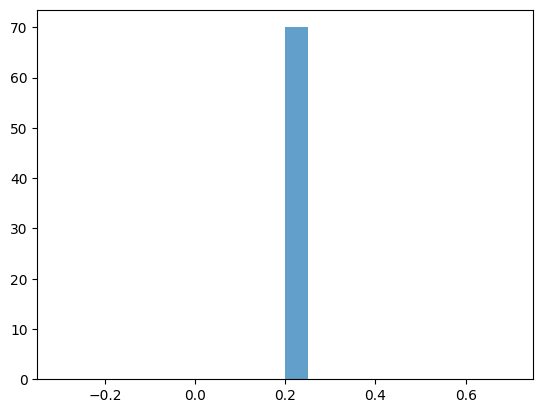

In [7]:
# all_connectomes: your (70, 68, 68) array from h5py
connectomes_binarized, densities, thresholds = binarize_to_fixed_density(all_connectomes, target=0.20)

print(f"densities (mean ± sd) : {densities.mean():.5f} ± {densities.std():.5f}")
# should read ≈ 0.20000 ± ~1e-4
plt.hist(densities, bins=20, alpha= 0.7)

# save np array connectomes_binarized
np.save(PREPROCESSED_PATH + "/connectomes_binarized.npy", connectomes_binarized)

connectomes_binarized.shape # (70, 68, 68)

## Get graph measures from empirical networks

In [10]:
# assume analyze_connectomes has been defined earlier
from src.structural_analysis.graph_measures import analyze_connectomes

df_graph_measures_bin = pd.DataFrame(analyze_connectomes(connectomes=connectomes_binarized, 
                                  distance_matrix=dist_mat, 
                                  comm_mode='estrada_scaled',
                                  rich_nodes_global=None,
                                  rich_top_percent=0.20
                                  ))


df_graph_measures_all = pd.DataFrame(analyze_connectomes(connectomes=all_connectomes, 
                                  distance_matrix=dist_mat, 
                                  comm_mode='estrada_scaled',
                                  rich_nodes_global=None,
                                  rich_top_percent=0.20
                                  ))
# save the dataframes
df_graph_measures_bin.to_csv(PREPROCESSED_PATH + "/df_graph_measures_bin.csv")
df_graph_measures_all.to_csv(PREPROCESSED_PATH + "/df_graph_measures_all.csv")

/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: divide by zero encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: overflow encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/Users/adrian/Documents/01_projects/14_4D_lab/src/structural_analysis/graph_measures.py:72: RuntimeWarning: invalid value encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T


In [21]:
df_graph_measures_bin

,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,0,0.020127,0.523178,0.385674,0.558604,11.441176,0.469829,45.503481,2.234416,41,53.039571
1,1,0.021016,0.559958,0.342192,0.552731,13.411765,0.457210,48.645978,2.046532,46,53.392462
2,2,0.021049,0.552275,0.418506,0.599042,13.411765,0.496317,47.508465,2.096576,47,60.049954
3,3,0.021261,0.556373,0.408566,0.570124,13.411765,0.469097,49.023596,2.069359,48,60.087251
4,4,0.020606,0.555897,0.336212,0.548212,13.411765,0.457649,48.363462,2.073749,52,52.655709
...,...,...,...,...,...,...,...,...,...,...,...
65,65,0.020709,0.559445,0.367106,0.566838,13.411765,0.469806,47.284030,2.049605,51,50.081903
66,66,0.020492,0.553995,0.402535,0.601771,13.411765,0.491271,46.985564,2.082529,51,57.814512
67,67,0.021370,0.558311,0.335142,0.558756,13.411765,0.469783,47.305744,2.056190,43,61.959989
68,68,0.021397,0.561509,0.342567,0.532443,13.411765,0.436678,47.695957,2.039508,44,52.333818


In [ ]:
# connectomes_binarized.T.shape, all_connectomes.T.shape # (68, 68, 70) -> (n, n, S)

((68, 68, 70), (68, 68, 70))

## Get identifiers

In [ ]:
df_identifiers = pd.read_csv(DATA_PATH + "/preprocessed/00_just_converted_for_matlab_and_python/data_10_consensus/05_roi_names_rsn_name_hemisphere_68.csv", 
                             header=None, 
                             names=["roi_name", "roi_name_short", "rsn_name", "hemisphere"])

# get hemi_ids 
hemi_id = [0 if x == "rh" else 1 for x in df_identifiers["hemisphere"]]
df_identifiers["hemi_id"] = hemi_id
hemi_id = np.array(hemi_id)

# strip \r, \n, spaces from rsn_name 
df_identifiers = df_identifiers.applymap(lambda x: x.strip() if isinstance(x, str) else x)  # strip \r, \n, spaces

# save identifiers
df_identifiers.to_csv(PREPROCESSED_PATH + "/df_identifiers.csv")
df_identifiers 

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_46467/1371428523.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_identifiers = df_identifiers.applymap(lambda x: x.strip() if isinstance(x, str) else x)  # strip \r, \n, spaces


,roi_name,roi_name_short,rsn_name,hemisphere,hemi_id
0,lateralorbitofrontal,LOF,ventralattention,rh,0
1,parsorbitalis,PORB,cinguloopercular,rh,0
2,frontalpole,FP,frontoparietal,rh,0
3,medialorbitofrontal,MOF,frontoparietal,rh,0
4,parstriangularis,PTRI,frontoparietal,rh,0
...,...,...,...,...,...
63,middletemporal,MT,other,lh,1
64,bankssts,BSTS,auditory,lh,1
65,superiortemporal,ST,auditory,lh,1
66,transversetemporal,TT,auditory,lh,1


## Get structural consensus connectomes

In [171]:
# Build consensus connectome from binarized connectomes -> Does not work, we are missing the hemi_id list. 
from netneurotools.networks import struct_consensus

consensus_conn_bin = struct_consensus(connectomes_binarized.T, distance=dist_mat, hemiid=hemi_id.reshape(-1, 1))
consensus_conn_all = struct_consensus(all_connectomes.T, distance=dist_mat, hemiid=hemi_id.reshape(-1, 1)) # , weighted=True)

# np.sum(consensus_conn_all-consensus_conn_bin) -> it makes a difference - I'll stay with the binarized connectome for now. (difference: 312) 
# consensus_conn_bin: Consensus connectome density: 0.19842
# consensus_conn_all: Consensus connectome density: 0.26690

# save consensus connectomes
np.save(PREPROCESSED_PATH + "/consensus_connectome_bin.npy", consensus_conn_bin)
np.save(PREPROCESSED_PATH + "/consensus_connectome_all.npy", consensus_conn_all)

Consensus connectome density: 0.19842
Consensus connectome density: 0.26690


Text(0.5, 0.98, 'Consensus Connectomes Differ If Binarization Is Performed Before The Calculation Of Consensus \n (and density also differs)')

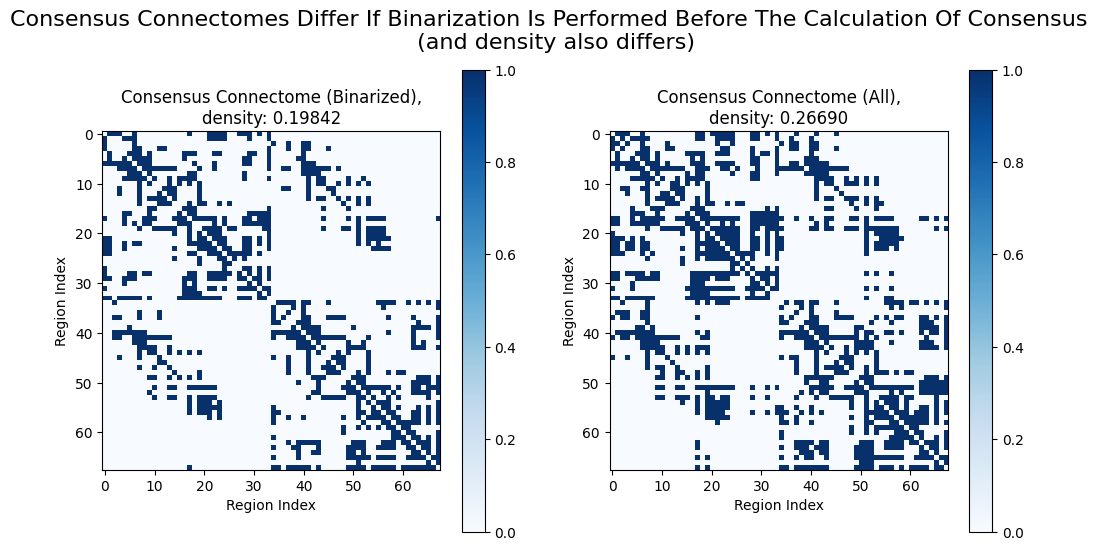

In [174]:
plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)

plt.imshow(consensus_conn_bin, cmap='Blues')
plt.colorbar()
plt.xlabel("Region Index")
plt.ylabel("Region Index")
consensus_density = bct.density_und(consensus_conn_bin)[0] 
print(f"Consensus connectome density: {consensus_density:.5f}")
plt.title("Consensus Connectome (Binarized),\ndensity: {:.5f}".format(consensus_density))


plt.subplot(1,2,2)
plt.imshow(consensus_conn_all, cmap='Blues')
plt.colorbar()
plt.xlabel("Region Index")
plt.ylabel("Region Index")
consensus_density = bct.density_und(consensus_conn_all)[0]  #
print(f"Consensus connectome density: {consensus_density:.5f}")
plt.title("Consensus Connectome (All),\ndensity: {:.5f}".format(consensus_density))

plt.suptitle("Consensus Connectomes Differ If Binarization Is Performed Before The Calculation Of Consensus \n (and density also differs)", fontsize=16)


